# **Data Collection**:

**Dataset Information:**

Dataset Name            : Drug Consumption(quantified)<br>
Dataset Characteristics :	Multivariate<br>
Subject Area            :	Social Science<br>
Associated Tasks        :	Classification<br>
Feature Type            :	Real<br>
Number of Instances     :	1885<br>
Number of Features      :32

**Source: UCI Machine Learning Repository**
> Database contains records for 1885 respondents. For each respondent 12 attributes are known: Personality measurements which include NEO-FFI-R (neuroticism, extraversion, openness to experience, agreeableness, and conscientiousness), BIS-11 (impulsivity), and ImpSS (sensation seeking), level of education, age, gender, country of residence and ethnicity.<br><br>
> All input attributes are originally categorical and are quantified. After quantification values of all input features can be considered as real-valued. In addition, participants were questioned concerning their use of 18 legal and illegal drugs (alcohol, amphetamines, amyl nitrite, benzodiazepine, cannabis, chocolate, cocaine, caffeine, crack, ecstasy, heroin, ketamine, legal highs, LSD, methadone, mushrooms, nicotine and volatile substance abuse and one fictitious drug (Semeron) which was introduced to identify over-claimers.

# Attribute Information:
1. ID is number of record in original database. Cannot be related to participant. It can be used for reference only.
2. Age (Real) is age of participant.
3. Gender (Real) is gender of participant.
4. Education (Real) is level of education of participant.
5. Country (Real) is country of current residence of participant.
6. Ethnicity (Real) is ethnicity of participant.
7. Nscore (Real) is NEO-FFI-R Neuroticism.
8. Escore (Real) is NEO-FFI-R Extraversion.
9. Oscore (Real) is NEO-FFI-R Openness to experience.
10. Ascore (Real) is NEO-FFI-R Agreeableness.
11. Cscore (Real) is NEO-FFI-R Conscientiousness.
12. Impulsive (Real) is impulsiveness measured by BIS-11.
13. SS (Real) is sensation seeing measured by ImpSS.
14. Alcohol is class of alcohol consumption.
15. Amphet is class of amphetamines consumption.
16. Amyl is class of amyl nitrite consumption.
17. Benzos is class of benzodiazepine consumption.
18. Caff is class of caffeine consumption.
19. Cannabis is class of cannabis consumption.
20. Choc is class of chocolate consumption.
21. Coke is class of cocaine consumption.
22. Crack is class of crack consumption.
23. Ecstasy is class of ecstasy consumption.
24. Heroin is class of heroin consumption.
25. Ketamine is class of ketamine consumption.
26. Legalh is class of legal highs consumption.
27. LSD is class of alcohol consumption.
28. Meth is class of methadone consumption.
29. Mushrooms is class of magic mushrooms consumption.
30. Nicotine is class of nicotine consumption.
31. Semer is class of fictitious drug Semeron consumption.
32. VSA is class of volatile substance abuse consumption.

# Data preprocessing:

In [7]:
import warnings

In [8]:
#import the necessary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
#set the backgroung style sheet
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

In [9]:
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.offline as py
from plotly.graph_objs import Scatter, Layout
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff

In [10]:
#load the csv file in a dataframe using read_csv function
df = pd.read_csv('/content/drug_consumption.csv')
copy_df = df.copy()        #make a copy of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1885 non-null   int64  
 1   Age        1885 non-null   float64
 2   Gender     1885 non-null   float64
 3   Education  1885 non-null   float64
 4   Country    1885 non-null   float64
 5   Ethnicity  1885 non-null   float64
 6   Nscore     1885 non-null   float64
 7   Escore     1885 non-null   float64
 8   Oscore     1885 non-null   float64
 9   Ascore     1885 non-null   float64
 10  Cscore     1885 non-null   float64
 11  Impulsive  1885 non-null   float64
 12  SS         1885 non-null   float64
 13  Alcohol    1885 non-null   object 
 14  Amphet     1885 non-null   object 
 15  Amyl       1885 non-null   object 
 16  Benzos     1885 non-null   object 
 17  Caff       1885 non-null   object 
 18  Cannabis   1885 non-null   object 
 19  Choc       1885 non-null   object 
 20  Coke    

In [11]:
#print first 5 rows of the dataset
df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


In [12]:
#description of dataset
df.describe()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS
count,1885.000000,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,945.294960,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,545.167641,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,1.000000,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,474.000000,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,946.000000,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,1417.000000,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,1888.000000,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


In [13]:
#check if any column or row contain a null value
df.isna().sum()

,0
ID,0
Age,0
Gender,0
Education,0
Country,0
Ethnicity,0
Nscore,0
Escore,0
Oscore,0
Ascore,0


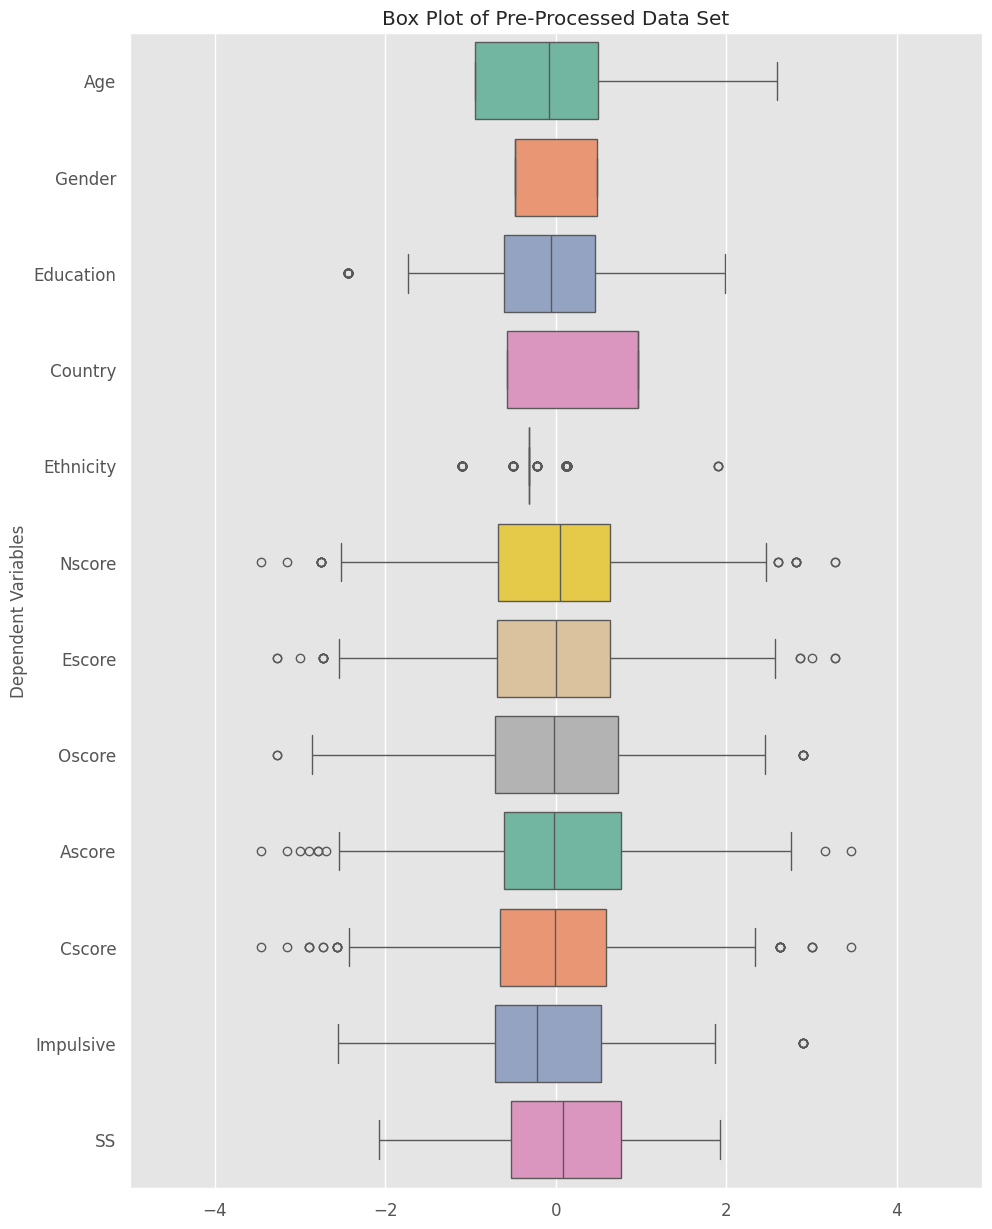

In [14]:
#plotting box plot for numerical values
feature_col_names = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
plt.style.use('ggplot')
f, ax = plt.subplots(figsize=(11, 15))

ax.set(xlim=(-5, 5))
plt.ylabel('Dependent Variables')
plt.title("Box Plot of Pre-Processed Data Set")
ax = sns.boxplot(data = df[feature_col_names],
  orient = 'h',
  palette = 'Set2')

In [15]:
#choosing columns that have outliers by observing the above box plot
outliers_cols=['Education','Ethnicity','Nscore','Escore','Oscore','Ascore','Cscore','Impulsive']


In [16]:
#dealing with outliers using winsorizaiton
from scipy.stats.mstats import winsorize
for i in outliers_cols:
  winsorized_data = winsorize(df[i], limits=[0.05, 0.05])
  #replacing bottom and top values with 5th and 95th percentile
  df[i]=winsorized_data


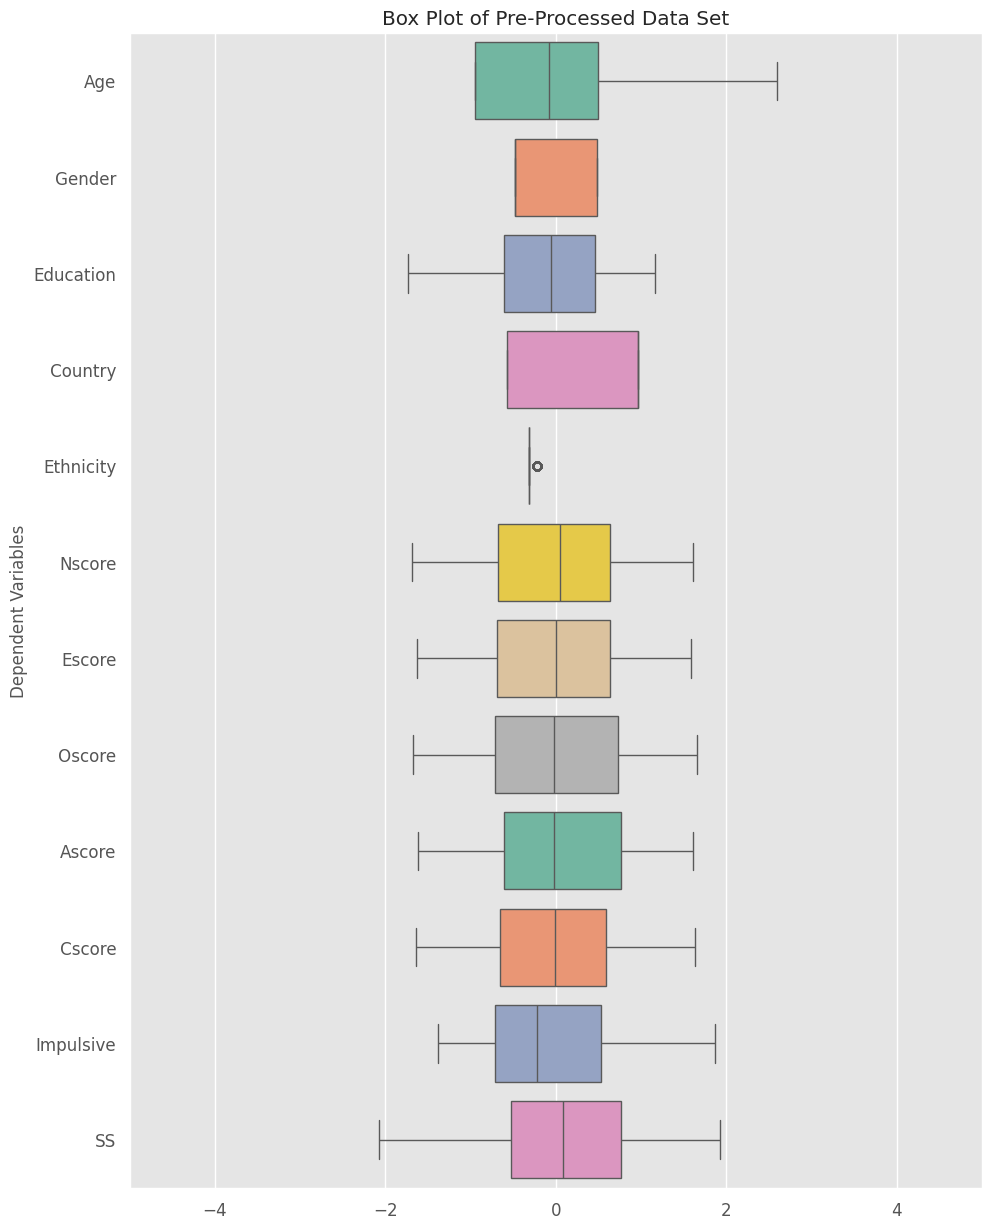

In [17]:
#After Winsorization
feature_col_names = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
plt.style.use('ggplot')
f, ax = plt.subplots(figsize=(11, 15))

ax.set(xlim=(-5, 5))
plt.ylabel('Dependent Variables')
plt.title("Box Plot of Pre-Processed Data Set")
ax = sns.boxplot(data = df[feature_col_names],
  orient = 'h',
  palette = 'Set2')

In [18]:

columns = ['Alcohol','Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack',
           'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms','Nicotine', 'Semer', 'VSA']
cp = ['User_Alcohol','User_Amphet', 'User_Amyl', 'User_Benzos', 'User_Caff', 'User_Cannabis', 'User_Choc', 'User_Coke', 'User_Crack',
           'User_Ecstasy', 'User_Heroin', 'User_Ketamine', 'User_Legalh', 'User_LSD', 'User_Meth', 'User_Mushrooms','User_Nicotine', 'User_Semer', 'User_VSA']

In [19]:
copy_df = df.copy()
copy_df

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,-0.22166,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.16365,0.96082,-0.31685,-0.67825,1.58487,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.16365,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.58487,1.65653,0.76096,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,1885,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.58487,0.58331,0.76096,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,1886,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.62090,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,1887,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.63340,0.29338,-1.62090,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [20]:
# performing label encoding
from sklearn.preprocessing import LabelEncoder
for column in columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

In [21]:
for column in columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
df.head(5)

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,-0.22166,0.31287,-0.57545,-0.58331,-0.91699,...,0,0,0,0,0,0,0,2,0,0
1,2,-0.07854,-0.48246,1.16365,0.96082,-0.31685,-0.67825,1.58487,1.43533,0.76096,...,4,0,2,0,2,3,0,4,0,0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,0,0,0,0,0,0,1,0,0,0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,0,0,2,0,0,0,0,2,0,0
4,5,0.49788,0.48246,1.16365,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,1,0,0,1,0,0,2,2,0,0


In [22]:
for column in columns:
    le = LabelEncoder()
    copy_df[column] = le.fit_transform(copy_df[column])
copy_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,-0.22166,0.31287,-0.57545,-0.58331,-0.91699,...,0,0,0,0,0,0,0,2,0,0
1,2,-0.07854,-0.48246,1.16365,0.96082,-0.31685,-0.67825,1.58487,1.43533,0.76096,...,4,0,2,0,2,3,0,4,0,0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,0,0,0,0,0,0,1,0,0,0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,0,0,2,0,0,0,0,2,0,0
4,5,0.49788,0.48246,1.16365,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,1,0,0,1,0,0,2,2,0,0


In [23]:
#Made a new column for each drug which contain the information that a user is using that drug or not

for i in range(len(columns)):
    copy_df.loc[((copy_df[columns[i]]==0) | (copy_df[columns[i]]==1)),cp[i]] = 'Non-user'
    copy_df.loc[((copy_df[columns[i]]==2) | (copy_df[columns[i]]==3) | (copy_df[columns[i]]==4) | (copy_df[columns[i]]==5) | (copy_df[columns[i]]==6)),cp[i]] = 'User'

In [24]:
copy_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,User_Ecstasy,User_Heroin,User_Ketamine,User_Legalh,User_LSD,User_Meth,User_Mushrooms,User_Nicotine,User_Semer,User_VSA
0,1,0.49788,0.48246,-0.05921,0.96082,-0.22166,0.31287,-0.57545,-0.58331,-0.91699,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,User,Non-user,Non-user
1,2,-0.07854,-0.48246,1.16365,0.96082,-0.31685,-0.67825,1.58487,1.43533,0.76096,...,User,Non-user,User,Non-user,User,User,Non-user,User,Non-user,Non-user
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,Non-user,Non-user,User,Non-user,Non-user,Non-user,Non-user,User,Non-user,Non-user
4,5,0.49788,0.48246,1.16365,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,User,User,Non-user,Non-user


# Data Visualization:

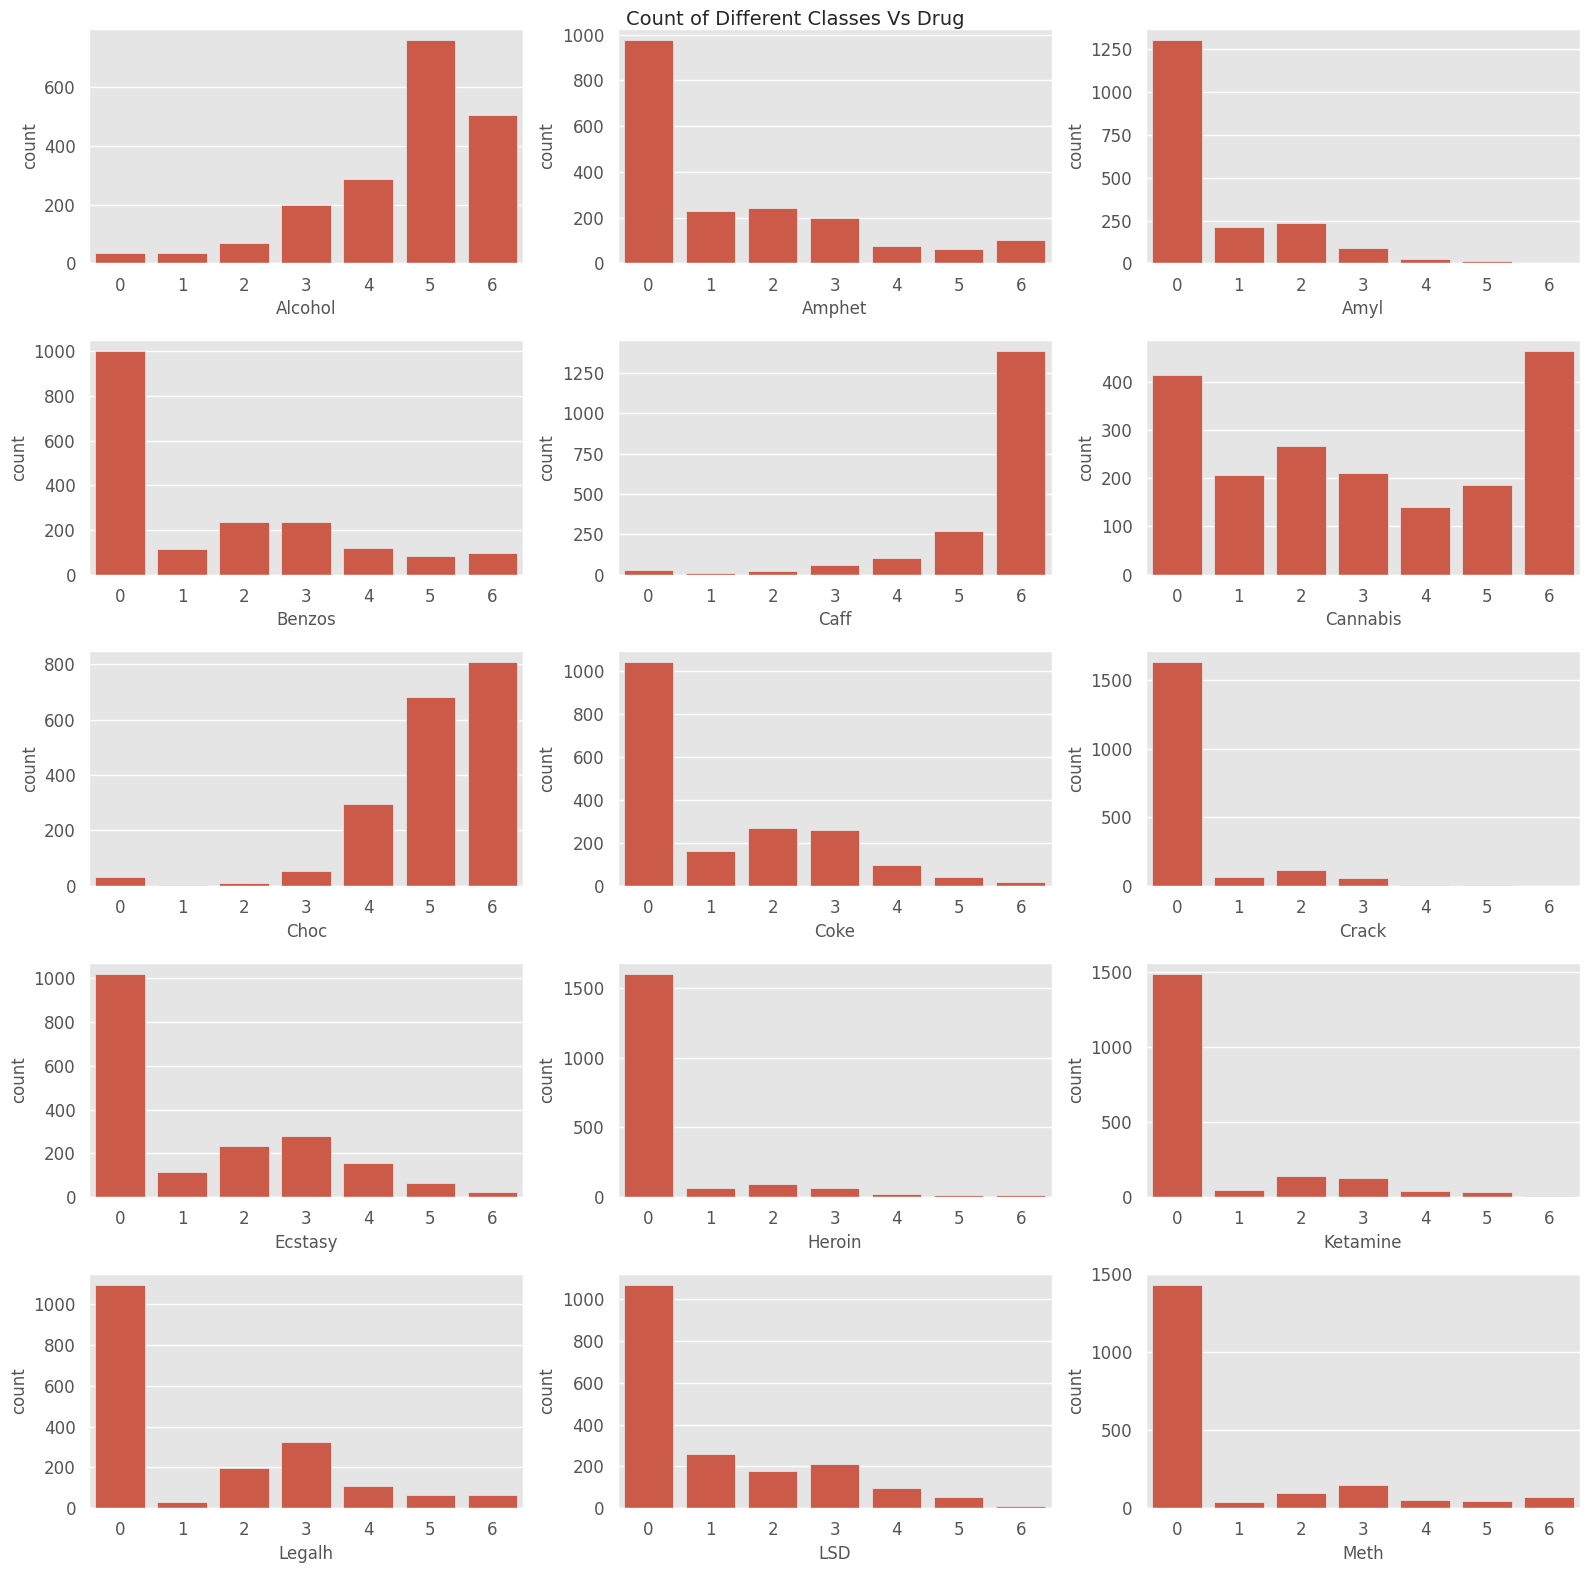

In [25]:
#count plot of differenct drugs with respect to classes
fig, axes = plt.subplots(5,3,figsize = (16,16))
fig.suptitle("Count of Different Classes Vs Drug",fontsize=14)
k=0
for i in range(5):
    for j in range(3):
        sns.countplot(x=columns[k], data=copy_df,ax=axes[i][j])
        k+=1

plt.tight_layout()
plt.show()

In [26]:
count_of_users = []
count_of_non_users = []

In [27]:
#finding out the count of users and non users of all the 18 different types of drugs
for i in range(len(columns)):
    s = copy_df.groupby([cp[i]])[columns[i]].count()
    count_of_users.append(s[1])
    count_of_non_users.append(s[0])

/tmp/ipykernel_5305/1765842918.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_5305/1765842918.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_5305/1765842918.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_5305/1765842918.py:5: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

In [28]:
print("Non-users:",count_of_non_users)
print("Users:",count_of_users)

Non-users: [np.int64(68), np.int64(1206), np.int64(1515), np.int64(1116), np.int64(37), np.int64(620), np.int64(35), np.int64(1198), np.int64(1694), np.int64(1134), np.int64(1673), np.int64(1535), np.int64(1123), np.int64(1328), np.int64(1468), np.int64(1191), np.int64(621), np.int64(1879), np.int64(1655)]
Users: [np.int64(1817), np.int64(679), np.int64(370), np.int64(769), np.int64(1848), np.int64(1265), np.int64(1850), np.int64(687), np.int64(191), np.int64(751), np.int64(212), np.int64(350), np.int64(762), np.int64(557), np.int64(417), np.int64(694), np.int64(1264), np.int64(6), np.int64(230)]


In [29]:
import plotly.graph_objs as go
from plotly.offline import iplot

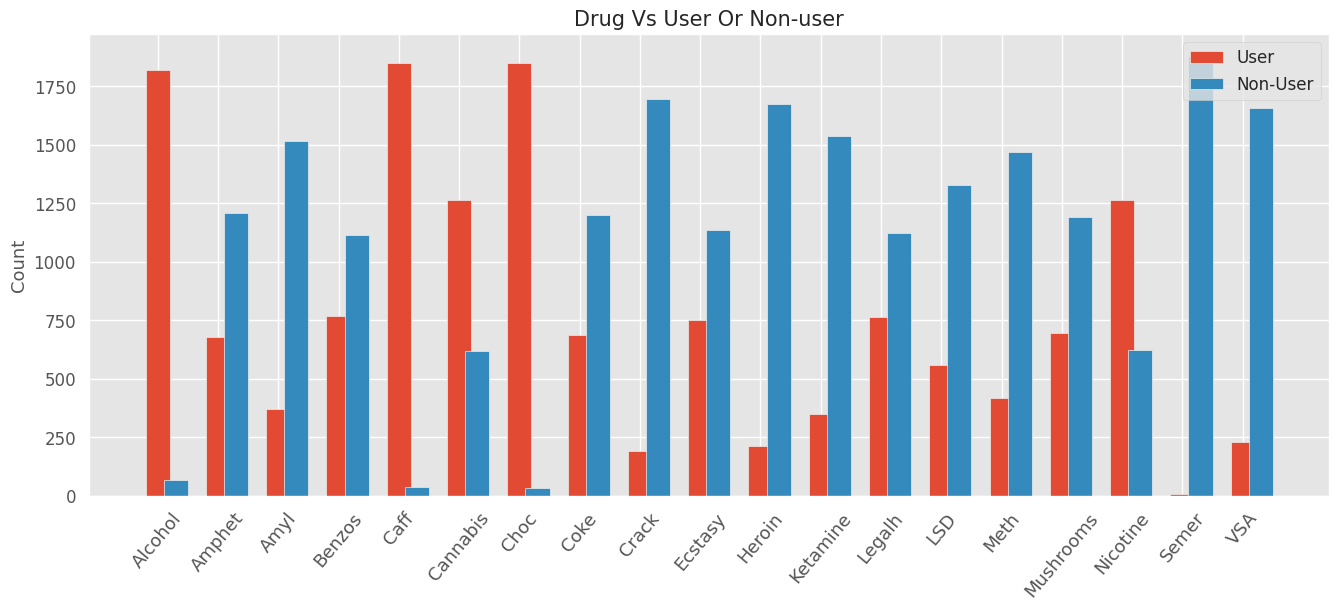

In [30]:
#bar plot of users and non-users with respect to all the 18 drugs
bins = np.arange(1,20,1)
plt.figure(figsize=(16,6))
plt.bar(bins+0,count_of_users,width=0.4,label ='User')
plt.bar(bins+.30,count_of_non_users,width=0.4,label ='Non-User')
plt.xticks(bins,columns,rotation=50,fontsize=13)
plt.ylabel("Count",fontsize=13)
plt.title("Drug Vs User Or Non-user",fontsize=15)
plt.legend()

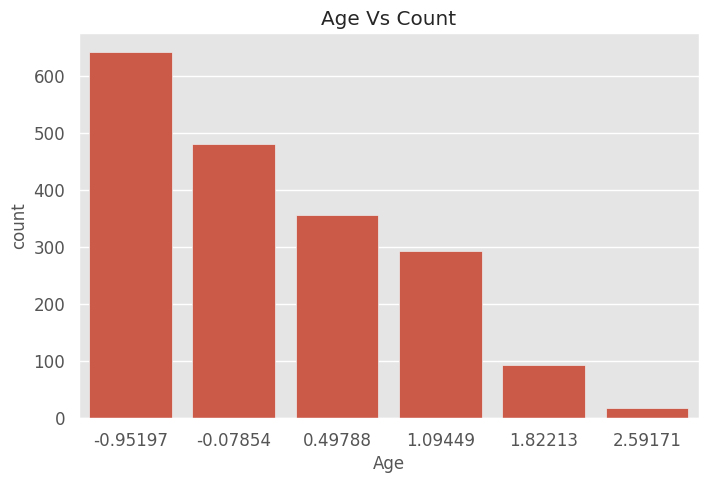

In [31]:
ax = sns.countplot(x='Age', data=df)
plt.title('Age Vs Count')
ax.figure.set_size_inches(8, 5)

In [32]:
copy_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,User_Ecstasy,User_Heroin,User_Ketamine,User_Legalh,User_LSD,User_Meth,User_Mushrooms,User_Nicotine,User_Semer,User_VSA
0,1,0.49788,0.48246,-0.05921,0.96082,-0.22166,0.31287,-0.57545,-0.58331,-0.91699,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,User,Non-user,Non-user
1,2,-0.07854,-0.48246,1.16365,0.96082,-0.31685,-0.67825,1.58487,1.43533,0.76096,...,User,Non-user,User,Non-user,User,User,Non-user,User,Non-user,Non-user
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,Non-user,Non-user,User,Non-user,Non-user,Non-user,Non-user,User,Non-user,Non-user
4,5,0.49788,0.48246,1.16365,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,Non-user,Non-user,Non-user,Non-user,Non-user,Non-user,User,User,Non-user,Non-user


In [33]:
for column in copy_df.columns:
    le = LabelEncoder()
    copy_df[column] = le.fit_transform(copy_df[column])

In [34]:
copy_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,User_Ecstasy,User_Heroin,User_Ketamine,User_Legalh,User_LSD,User_Meth,User_Mushrooms,User_Nicotine,User_Semer,User_VSA
0,0,2,1,4,6,1,18,8,8,5,...,0,0,0,0,0,0,0,1,0,0
1,1,1,0,6,6,0,8,22,21,16,...,1,0,1,0,1,1,0,1,0,0
2,2,2,0,4,6,0,10,17,6,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,1,6,6,0,13,6,12,15,...,0,0,1,0,0,0,0,1,0,0
4,4,2,1,6,6,0,22,0,9,9,...,0,0,0,0,0,0,1,1,0,0


In [35]:
copy_df['Count'] = pd.Series()
copy_df['Count'] = copy_df['Count'].fillna(value = 0.0)

for i in cp:
    copy_df['Count']+=copy_df[i]

/tmp/ipykernel_5305/2659735226.py:2: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [36]:
copy_df.head()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,User_Heroin,User_Ketamine,User_Legalh,User_LSD,User_Meth,User_Mushrooms,User_Nicotine,User_Semer,User_VSA,Count
0,0,2,1,4,6,1,18,8,8,5,...,0,0,0,0,0,0,1,0,0,6.0
1,1,1,0,6,6,0,8,22,21,16,...,0,1,0,1,1,0,1,0,0,12.0
2,2,2,0,4,6,0,10,17,6,0,...,0,0,0,0,0,0,0,0,0,4.0
3,3,0,1,6,6,0,13,6,12,15,...,0,1,0,0,0,0,1,0,0,8.0
4,4,2,1,6,6,0,22,0,9,9,...,0,0,0,0,0,1,1,0,0,6.0


In [37]:
pk = copy_df['Count'].value_counts()
pk

,count
Count,
3.0,312
4.0,236
5.0,167
6.0,136
10.0,126
11.0,116
9.0,114
13.0,103
8.0,103


In [38]:
df['Country'].value_counts()
con = ['UK','USA','Canada','Australia','Ireland','New Zealand']

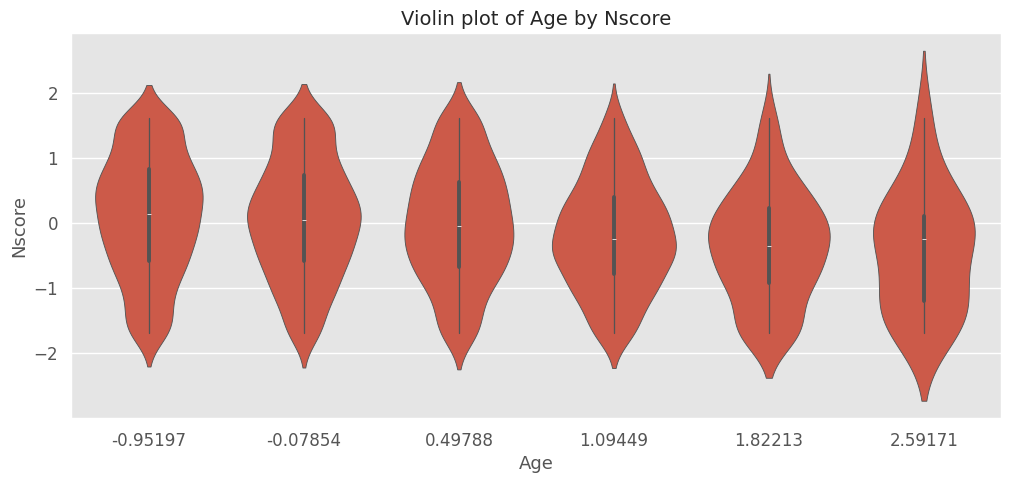

In [39]:
#violin plot of age with Nscore values
plt.figure(figsize=(12,5))
sns.violinplot(x='Age', y='Nscore', data=df)
plt.title('Violin plot of Age by Nscore',fontsize=14)
plt.xlabel('Age',fontsize=13)
plt.ylabel('Nscore',fontsize=13)
plt.show()

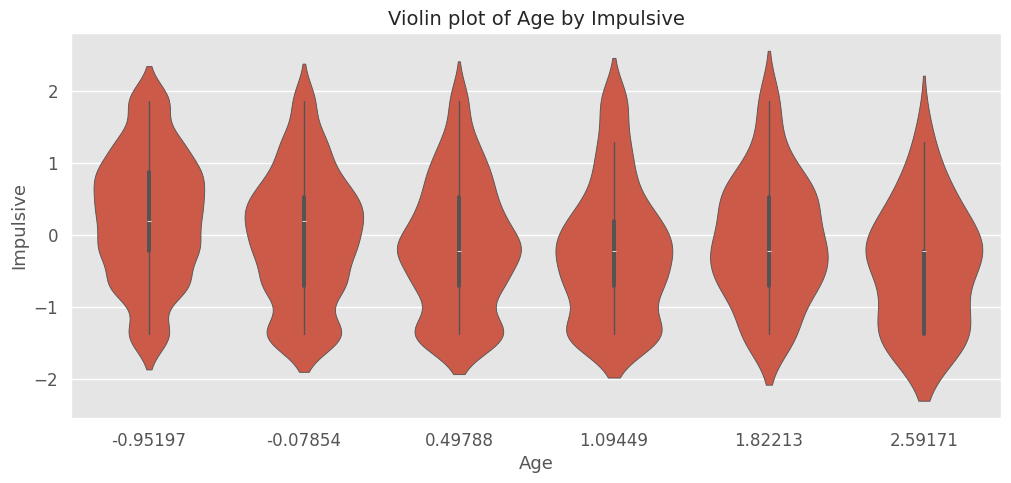

In [40]:
#violin plot of Age and Impulsive
plt.figure(figsize=(12,5))
sns.violinplot(x='Age', y='Impulsive', data=df)
plt.title('Violin plot of Age by Impulsive',fontsize=14)
plt.xlabel('Age',fontsize=13)
plt.ylabel('Impulsive',fontsize=13)
plt.show()

# Correlation matrix:

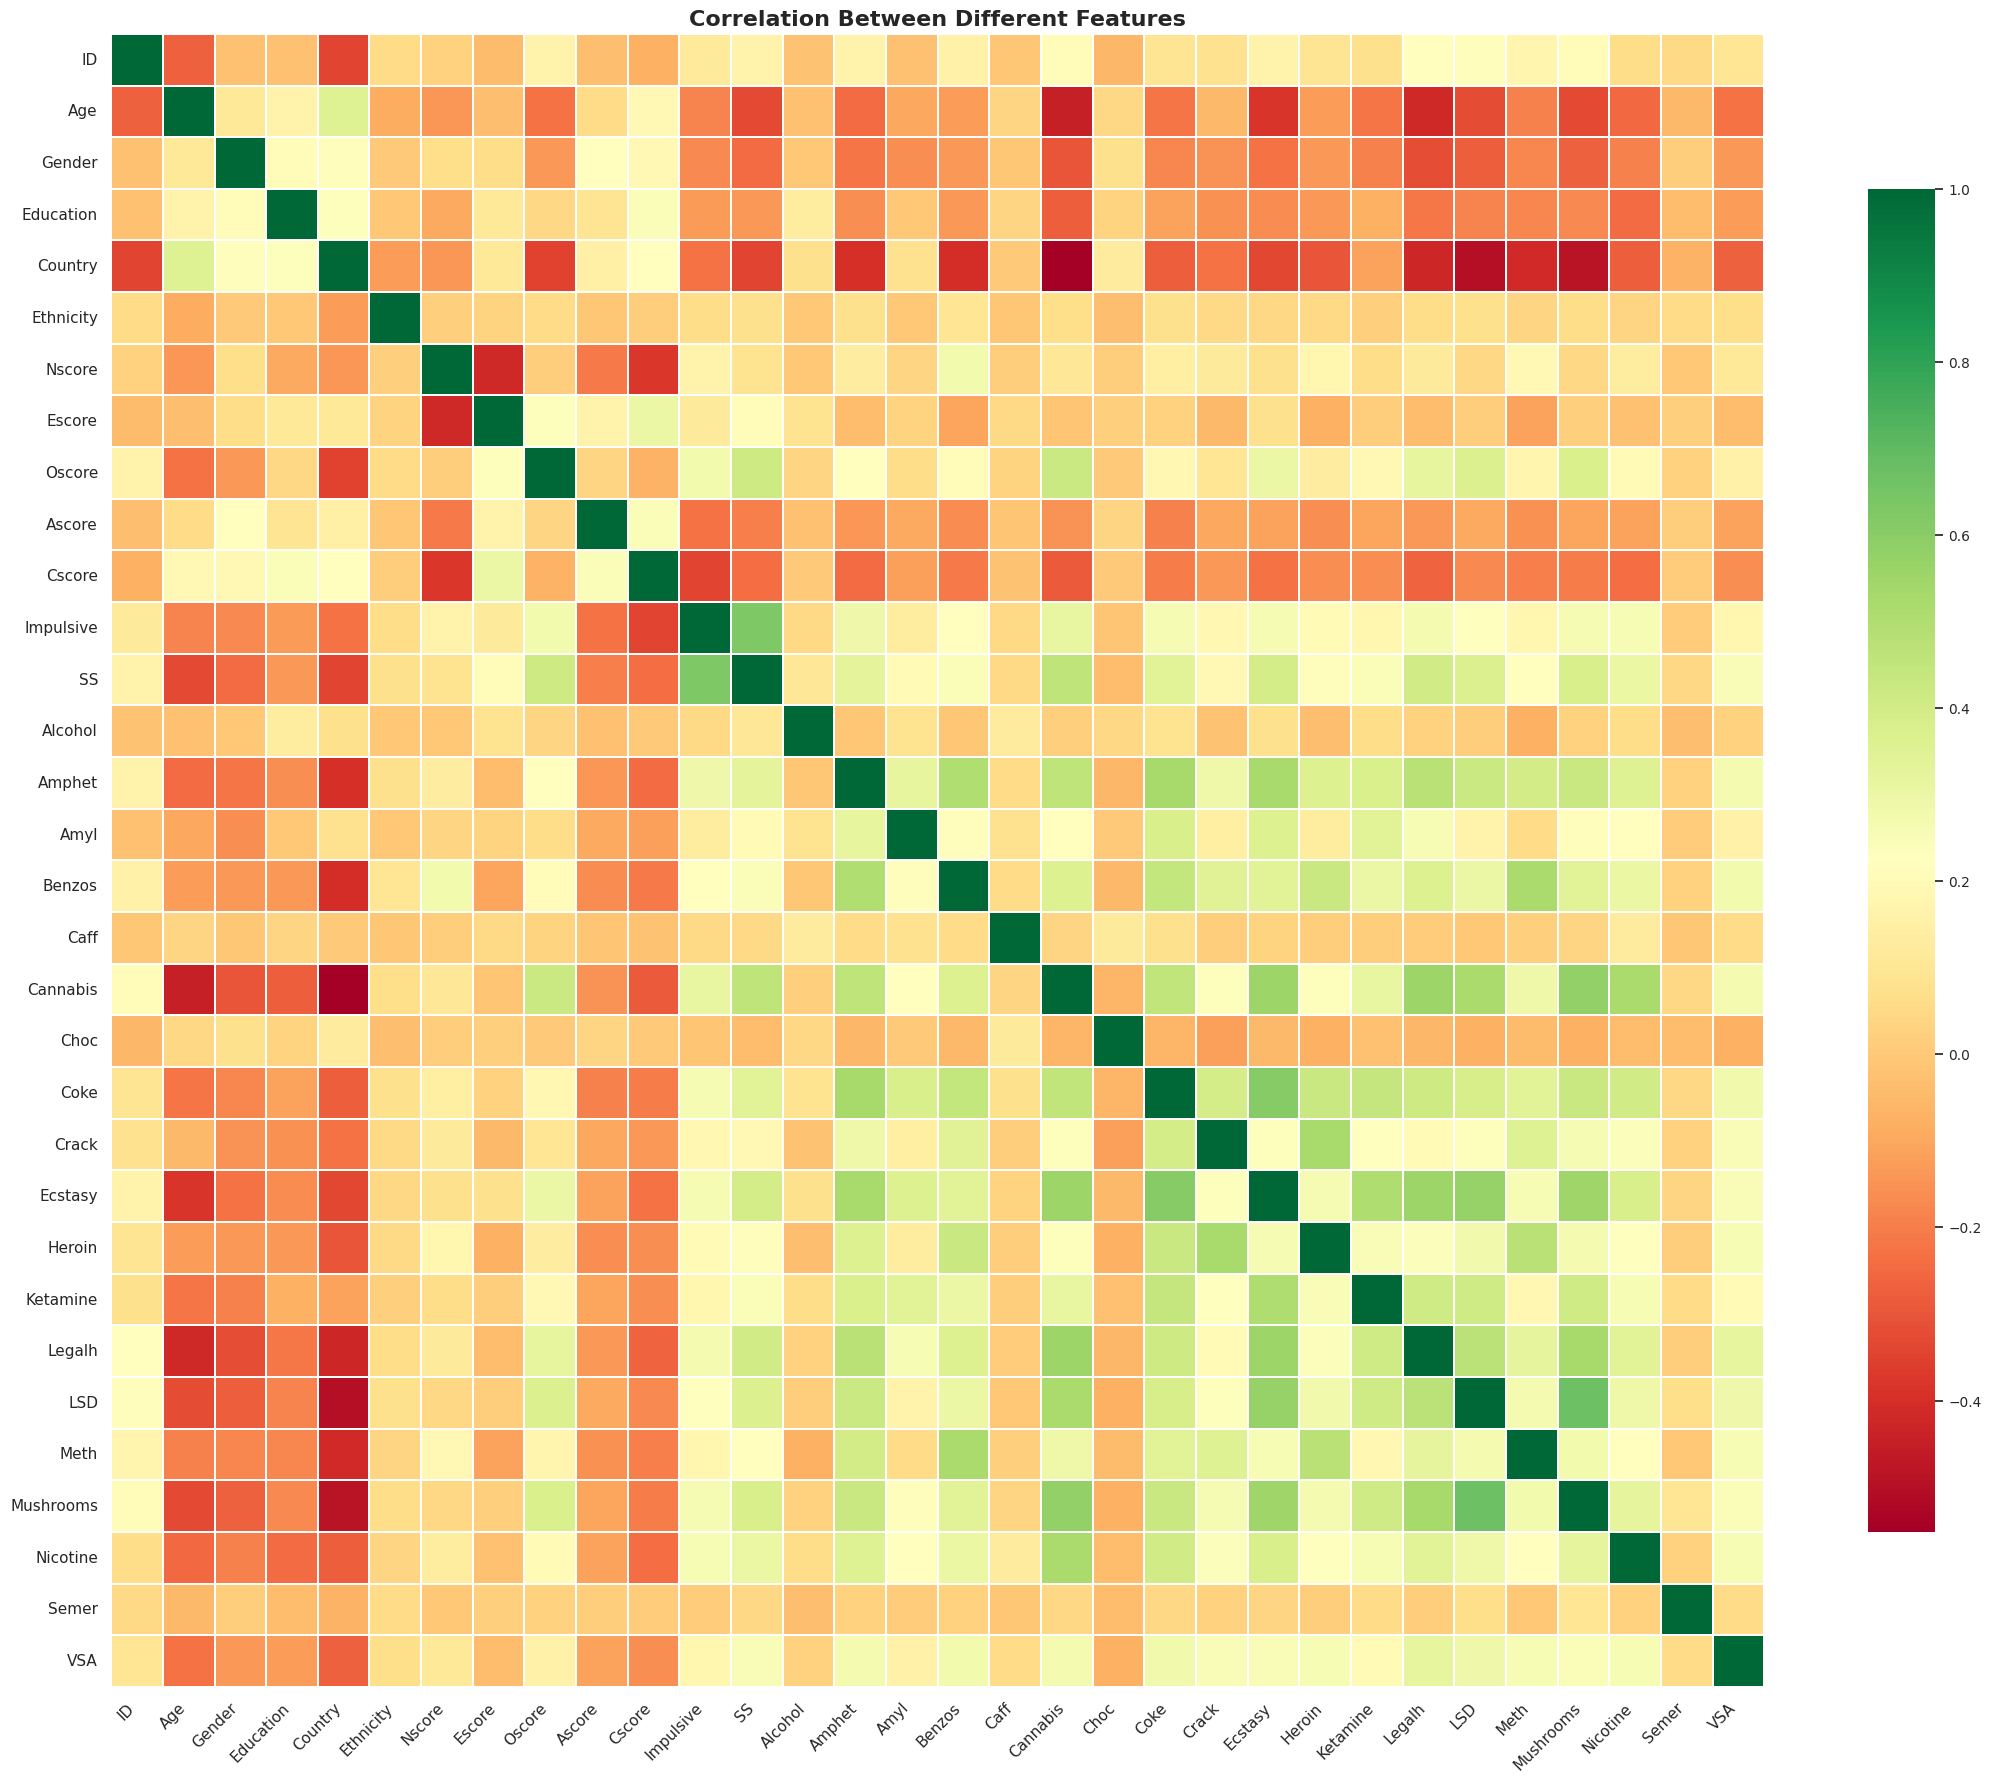

In [41]:
corrmat = df.select_dtypes(include=['int64', 'float64']).corr()

plt.figure(figsize=(22, 18))
sns.set(font_scale=0.9)

sns.heatmap(
    corrmat,
    cmap='RdYlGn',
    annot=False,
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11)
plt.title("Correlation Between Different Features", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Data splitting:

In [42]:
from sklearn.model_selection import train_test_split

feature_col_names = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity', 'Nscore',
       'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']

predicted_class_names = ['VSA']

X = df[feature_col_names].values
y = df[predicted_class_names].values

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Feature Scaling:

In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [45]:
from sklearn import metrics
from sklearn.metrics import roc_curve,auc


def report_performance(model):

    model_test = model.predict(X_test)

    print("\n\nConfusion Matrix:")
    print("{0}".format(metrics.confusion_matrix(y_test, model_test)))
    print("\n\nClassification Report: ")
    print(metrics.classification_report(y_test, model_test))
    #cm = metrics.confusion_matrix(y_test, model_test)
    #plot_confusion_metrix(y_test, model_test)

In [46]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer


## Random Forest:

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [48]:
random_classifier=RandomForestClassifier(n_estimators=100, random_state=42)

In [49]:
random_classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(random_state=42)

In [50]:
y_pred = random_classifier.predict(X_test)

In [51]:
y_pred = y_pred.reshape(-1, 1)

# Now you can safely take argmax along axis 1
y_pred_labels_random = np.argmax(y_pred, axis=1)

In [52]:
y_pred_labels_random

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [53]:
from sklearn.metrics import accuracy_score
random_forest_accuracy = accuracy_score(y_test, y_pred_labels_random)
random_forest_accuracy

0.765017667844523

In [54]:
importances = random_classifier.feature_importances_

In [55]:
importances=list(importances)

In [56]:
for i,j in zip(feature_col_names,importances):
  print(i," ",j)

Age   0.060407550673077265
Gender   0.026765955048792554
Education   0.07002170707255143
Country   0.06407055621545694
Ethnicity   0.012410404761032941
Nscore   0.12494606461971929
Escore   0.10782588428621986
Oscore   0.11619293527423812
Ascore   0.12317081714604537
Cscore   0.11794581069811795
Impulsive   0.08535617529016633
SS   0.0908861389145821


In [57]:
report_performance(random_classifier)



Confusion Matrix:
[[432   1   0   0   0   0   0]
 [ 58   0   1   0   0   0   0]
 [ 39   0   0   0   0   0   0]
 [ 22   0   0   0   0   0   0]
 [  1   0   1   0   0   0   0]
 [  9   0   0   0   0   0   0]
 [  2   0   0   0   0   0   0]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       433
           1       0.00      0.00      0.00        59
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        22
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         2

    accuracy                           0.76       566
   macro avg       0.11      0.14      0.12       566
weighted avg       0.59      0.76      0.66       566



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



# SVM Classifier:

In [58]:
from sklearn.svm import SVC

In [59]:
svm_classifier = SVC(kernel='rbf', C=8, gamma='scale', random_state=42)

In [60]:
svm_classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



SVC(C=8, random_state=42)

In [61]:
y_pred_svm = svm_classifier.predict(X_test)

In [62]:
y_pred_svm

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 0,

In [63]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_accuracy

0.7455830388692579

In [64]:
report_performance(svm_classifier)



Confusion Matrix:
[[416   4  11   1   1   0   0]
 [ 54   2   3   0   0   0   0]
 [ 34   1   4   0   0   0   0]
 [ 20   1   1   0   0   0   0]
 [  0   0   1   1   0   0   0]
 [  9   0   0   0   0   0   0]
 [  2   0   0   0   0   0   0]]


Classification Report: 
              precision    recall  f1-score   support

           0       0.78      0.96      0.86       433
           1       0.25      0.03      0.06        59
           2       0.20      0.10      0.14        39
           3       0.00      0.00      0.00        22
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         2

    accuracy                           0.75       566
   macro avg       0.18      0.16      0.15       566
weighted avg       0.63      0.75      0.67       566



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



#Logistic Regression:

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

lr_classifier = LogisticRegression(
    multi_class='multinomial', solver='lbfgs',
    max_iter=1000, random_state=42
)
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression Accuracy: {lr_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.




Logistic Regression Accuracy: 0.7633

Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87       433
           1       0.50      0.02      0.03        59
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        22
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00         2

    accuracy                           0.76       566
   macro avg       0.18      0.14      0.13       566
weighted avg       0.64      0.76      0.67       566



# Accuracy Comparision before hyperparameter tuning:

In [66]:
models = ['RandomForest','SVM', 'LogisticRegression']
accuracy = [random_forest_accuracy,svm_accuracy,lr_accuracy]


/tmp/ipykernel_5305/4103693124.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




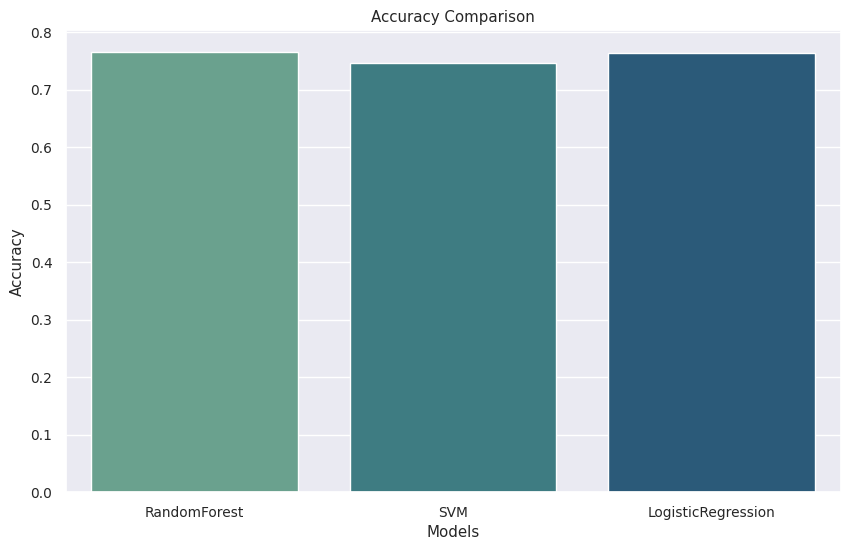

In [67]:
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracy, palette='crest')
plt.title('Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# Hyperparameter Tuning:

In [68]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (important for LR & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
lr = LogisticRegression()
lr_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "saga"],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring="accuracy")
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
lr_pred = best_lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [70]:
lr_acc

0.7718832891246684

In [78]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [20, 30],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring="accuracy")
rf_grid.fit(X_train, y_train)   # no scaling needed

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d

In [79]:
rf_acc

0.76657824933687

In [74]:
svm = SVC(probability=True)

svm_params = {
    "C": [1, 10, 50],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto", 0.01, 1],
    "class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(svm, svm_params, cv=5, scoring="accuracy")
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_
svm_pred = best_svm.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408

In [75]:
svm_acc

0.7718832891246684

In [76]:
models = ["Logistic Regression", "Random Forest", "SVM"]
accuracy = [lr_acc, rf_acc, svm_acc]

comparison_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.771883
1        Random Forest  0.766578
2                  SVM  0.771883


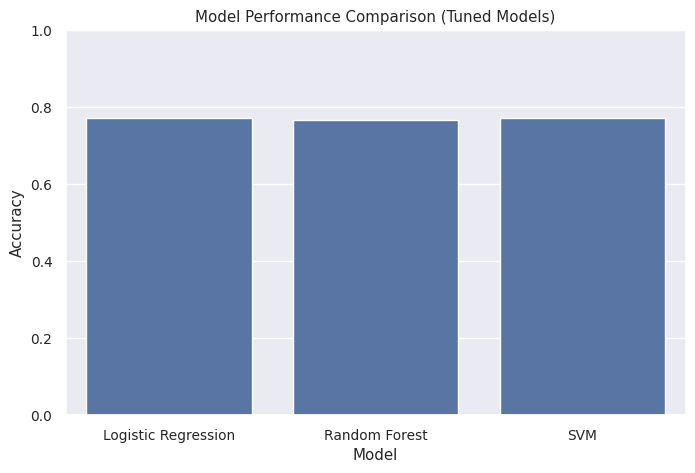

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison_df
)

plt.title("Model Performance Comparison (Tuned Models)")
plt.ylim(0, 1)

plt.show()